# **FEC Quant Recruitment:*

# PHASE-1: DATA GATHERING AND PRE-PROCESSING.


In [1]:
# 1. Installing the required packages.
!pip install yfinance pandas numpy matplotlib scipy statsmodels -q

# 2. Import all necessary libraries
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import scipy
import statsmodels.api as sm

# 3. Set standard plotting style for better looking equity curves
plt.style.use('seaborn-v0_8-darkgrid')

# 4. Sanity Check
print("All libraries imported successfully,and the Environment is ready.")

All libraries imported successfully,and the Environment is ready.


In [2]:
# Setting up the list of 10 stocks provided in the problem statement.
target_stocks = ['AAPL', 'MSFT', 'NVDA', 'JPM', 'GS', 'CAT', 'XOM', 'PG', 'JNJ', 'PFE']

# Pulling 7 full years of daily data (from starting of 2018 to end of 2024).
# auto_adjust=True is crucial here so we won't get skewed by stock splits and dividend.
historical_data = yf.download(target_stocks, start='2018-01-01', end='2025-01-01', auto_adjust=True)

# Checking how the columns look, expecting a MultiIndex structure.
print("Columns in our downloaded data:")
print(historical_data.columns)

# Extracting just the closing prices and the volume since that's all we need for our signals
adjusted_prices = historical_data['Close']
trade_volume = historical_data['Volume']

# Quick sanity check on the dimensions. Should be roughly 1762 trading days and 10 columns.
print(f"\nShape of Adjusted Prices: {adjusted_prices.shape}")
print(f"Shape of Trade Volume: {trade_volume.shape}")

[*********************100%***********************]  10 of 10 completed

Columns in our downloaded data:
MultiIndex([( 'Close', 'AAPL'),
            ( 'Close',  'CAT'),
            ( 'Close',   'GS'),
            ( 'Close',  'JNJ'),
            ( 'Close',  'JPM'),
            ( 'Close', 'MSFT'),
            ( 'Close', 'NVDA'),
            ( 'Close',  'PFE'),
            ( 'Close',   'PG'),
            ( 'Close',  'XOM'),
            (  'High', 'AAPL'),
            (  'High',  'CAT'),
            (  'High',   'GS'),
            (  'High',  'JNJ'),
            (  'High',  'JPM'),
            (  'High', 'MSFT'),
            (  'High', 'NVDA'),
            (  'High',  'PFE'),
            (  'High',   'PG'),
            (  'High',  'XOM'),
            (   'Low', 'AAPL'),
            (   'Low',  'CAT'),
            (   'Low',   'GS'),
            (   'Low',  'JNJ'),
            (   'Low',  'JPM'),
            (   'Low', 'MSFT'),
            (   'Low', 'NVDA'),
            (   'Low',  'PFE'),
            (   'Low',   'PG'),
            (   'Low',  'XOM'),
        

In [3]:
# 1. Handling any missing data points in prices.
# I will use forward fill first (carry the last known valid price forward)
# Then backward fill as a safety net if any stock had missing data on day one.
adjusted_prices = adjusted_prices.ffill().bfill()

# 2. Handle missing data points in volume;
# If volume data is missing, it implies zero market activity or a market halt on that day.
# Replacing NaN with 0.
trade_volume = trade_volume.fillna(0)

# 3. Using assertions to guarantee absolutely zero null values remain in data.
# If an assertion fails, Python throws an error; if it passes, it stays silent.
# It is Safety check to make sure no NaN values mess up the calculations later.
assert adjusted_prices.isna().sum().sum() == 0, "Error: Found remaining missing values in prices!"
assert trade_volume.isna().sum().sum() == 0, "Error: Found remaining missing values in trade volume!"

# 4. Confirmation output
print("All gaps are filled, data cleaning verified with zero null values.")

All gaps are filled, data cleaning verified with zero null values.


# Now, If we plot raw prices, stocks with high absolute share prices will skew the graph, making it impossible to see the relative trends of cheaper stocks. We will solve this by normalizing the data so every stock starts exactly at 1.0 on day one.
Also I am plotting all the curves in their respective different color to show the exact data.

Here in this plot clearly the NVDA (Nvidia) line show a massive, exponential spike towards the right side of the graph (2023-2024), which is pink in color.

Stocks like PFE (Pfizer) remain relatively flat near the bottom compared to the others shown in gray-brown in color and is almost flat in the entire curve.

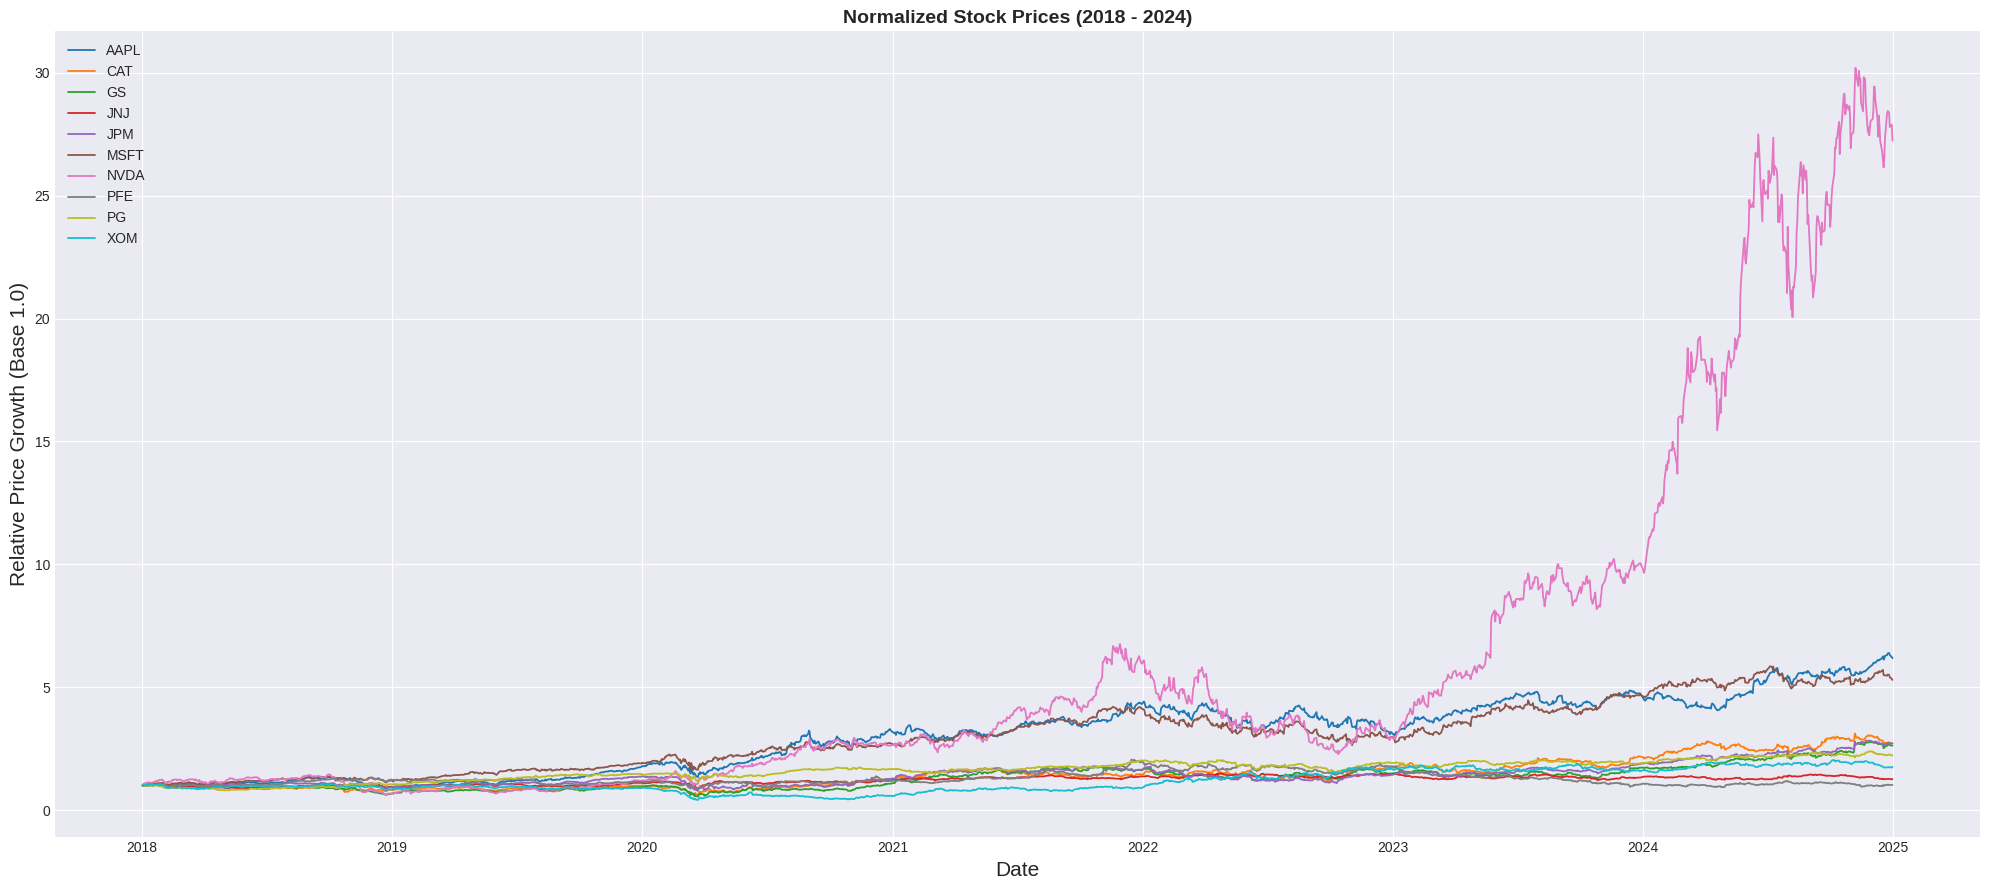

In [4]:
# 1. Normalizing the prices so every stock starts at 1.0 on day one.
# This is important to compare relative 7-year growth of the tickers.
normalized_prices = adjusted_prices / adjusted_prices.iloc[0]

# 2. Seting up and plotting the normalized equity curves.
plt.figure(figsize=(20, 9))
plt.plot(normalized_prices, linewidth=1.3)

# 3. Adding format and fix the legend by passing the exact DataFrame column order
plt.title('Normalized Stock Prices (2018 - 2024)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=15)
plt.ylabel('Relative Price Growth (Base 1.0)', fontsize=15)

# Passing normalized_prices.columns guarantees the labels match the alphabetical line order perfectly
plt.legend(normalized_prices.columns, loc='upper left')

plt.tight_layout()
plt.show()

# Trading Volume chart and actual data distribution for PHASE-1:

The chart will render seamlessly over the full 7-year time horizon without gaps or runtime calculation drops, because we cleaned the volume data earlier.

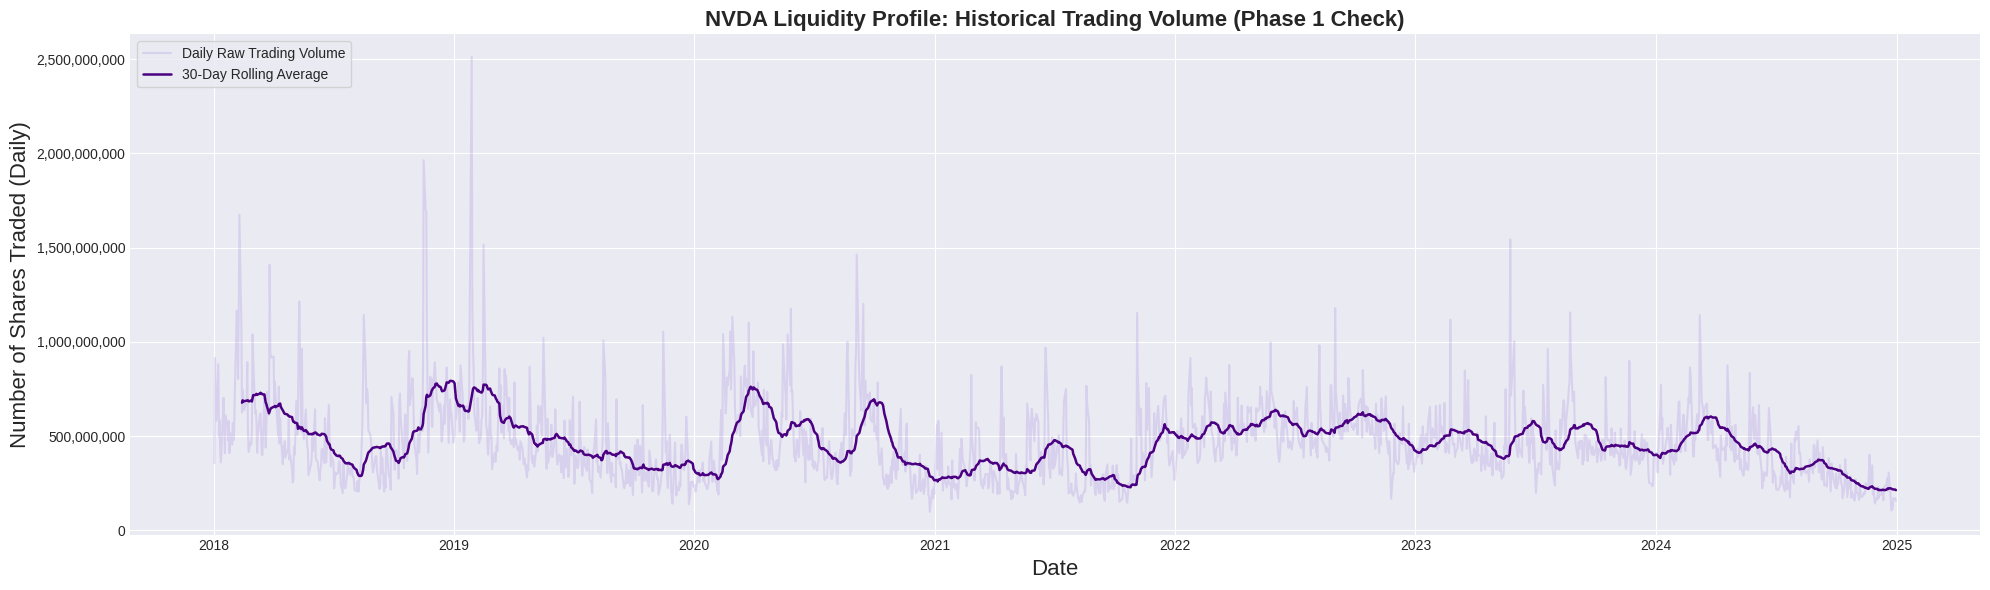

In [5]:
# 1. Computing a 30-day moving average of daily volume to smooth out extreme single-day spikes
# We isolate NVDA here to match our prior analysis of its massive market regime change
nvda_volume_smoothed = trade_volume['NVDA'].rolling(window=30).mean()

# 2. Initializing the plot layout.
plt.figure(figsize=(20, 6))

# Plotting the raw daily volume with high transparency (alpha) so the noise is visible but muted
plt.plot(trade_volume['NVDA'], color='mediumpurple', alpha=0.2, label='Daily Raw Trading Volume')

# Overlaying the 30-day moving average line to highlight structural liquidity trends.
plt.plot(nvda_volume_smoothed, color='indigo', linewidth=1.8, label='30-Day Rolling Average')

# 3. Apply institutional-grade formatting.
plt.title('NVDA Liquidity Profile: Historical Trading Volume (Phase 1 Check)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=16)
plt.ylabel('Number of Shares Traded (Daily)', fontsize=16)
plt.legend(loc='upper left', frameon=True)

# Formatting the Y-axis to display numbers cleanly.
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

 # Exploratory Data Analysis: Asset Correlation Matrix

As a preliminary step, I examine the correlation matrix of the 10 selected stocks.Understanding cross-asset relationships before constructing a momentum-based portfolio.

As, High correlations (above 0.8) may indicate concentration risk and reduce the benefits of diversification. This helps the risk characteristics of the momentum strategy.

In the following heat map, We can clearly see that AAPL and MSFT are highly correlated, but there is enough variance in the rest of the stocks to proceed.

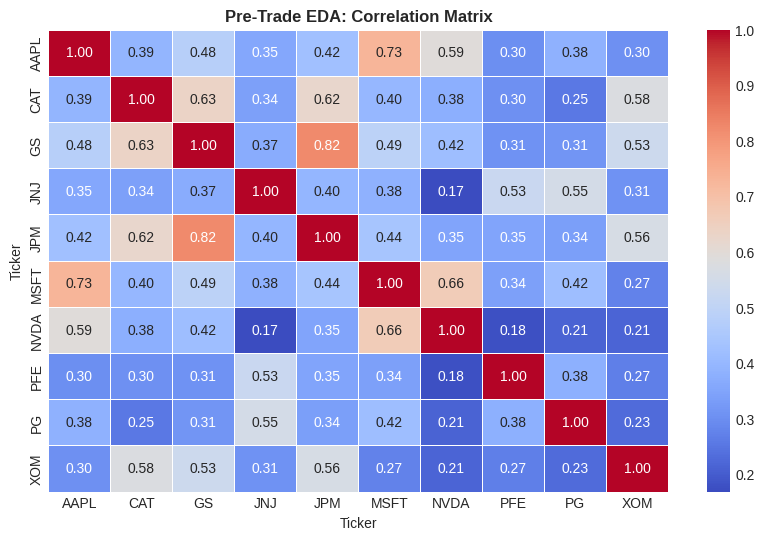

In [6]:
# Checking the Asset Correlation Matrix (EDA)
# Before building the signal engine, I want to check if my 10-stocks are actually diversified or not.
# If they are highly correlated (> 0.8), the momentum strategy will suffer from massive concentration risk during sector drawdowns.

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
# Calculate daily correlation across all the stocks(tickers).
corr_matrix = adjusted_prices.pct_change().corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Pre-Trade EDA: Correlation Matrix', fontsize=12, fontweight='bold')
plt.show()

# PHASE-2 SIGNAL GENERATION AND TECHNICAL INDICATORS.

calculating the 20-day Exponential Moving Average (fast trend line) and the 50-day Exponential Moving Average (slow trend line) across all 10-stock. Using Exponential Moving Averages (EMAs) instead of Simple Moving Averages (SMAs) which ensures that recent price actions carry more weight, then minimizing structural lag when capturing momentum shifts.

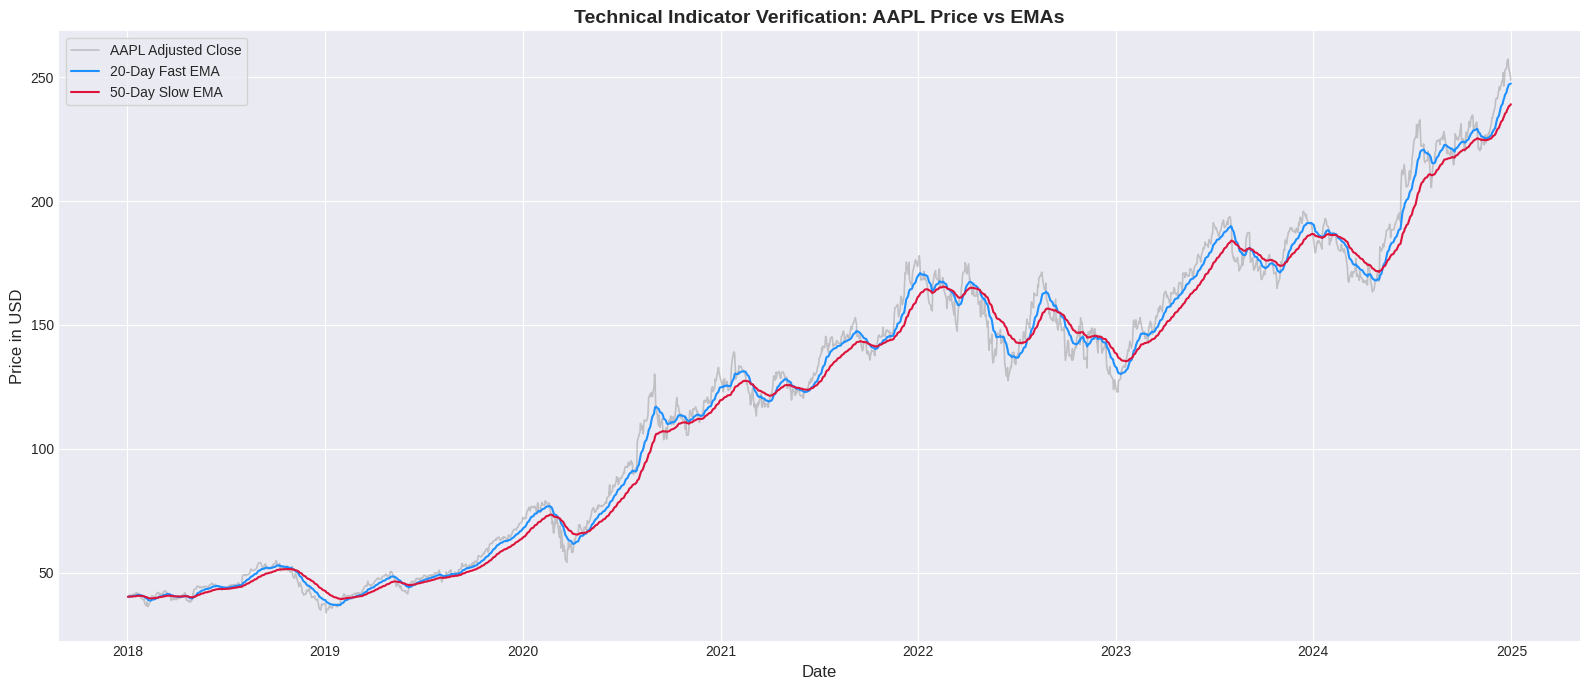

 Fast EMA shape (1761, 10) and Slow EMA shape (1761, 10) match perfectly.


In [7]:
# 1. Calculating the 20-day Exponential Moving Average (Fast trend indicator)
# Setting adjust=False implements the standard recursive smoothing formula.
fast_ema_20 = adjusted_prices.ewm(span=20, adjust=False).mean()

# 2. Calculating the 50-day Exponential Moving Average (Slow trend indicator)
slow_ema_50 = adjusted_prices.ewm(span=50, adjust=False).mean()

# 3. Create a clean verification plot for a single asset (AAPL) to visually verify all the indicators.
plt.figure(figsize=(16, 7))

# Ploting raw prices with some transparency so the EMAs stand out cleanly in my graph.
plt.plot(adjusted_prices['AAPL'], label='AAPL Adjusted Close', color='gray', alpha=0.4, linewidth=1.2)
plt.plot(fast_ema_20['AAPL'], label='20-Day Fast EMA', color='dodgerblue', linewidth=1.5)
plt.plot(slow_ema_50['AAPL'], label='50-Day Slow EMA', color='crimson', linewidth=1.5)

# Adding labels in this chart.
plt.title('Technical Indicator Verification: AAPL Price vs EMAs', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price in USD', fontsize=12)
plt.legend(loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

# 4. Final confirmation log to check DataFrame matrix alignment.
print(f" Fast EMA shape {fast_ema_20.shape} and Slow EMA shape {slow_ema_50.shape} match perfectly.")

# Now... we will calculate the Relative Strength Index (RSI) with a standard 14-day lookback period across all 10 stocks.

RSI is a momentum oscillator that measures the speed and change of price movements, alternating between 0 and 100. It will serve as our quality filter to ensure our momentum strategy does not buy into overbought conditions or sell into oversold conditions.

Here, the factor of 1e-10 added to the average_losses denominator because, In a raw historical backtest, if a stock goes completely sideways or gets suspended from trading for a few days, its average_losses drops to exactly zero. so without this small factor, Python will evaluate the line as a division by zero, creating an inf or NaN value that will silently poison my trade signals.

In [8]:
# 1. Calculating the daily price differences across all the stocks.
price_delta = adjusted_prices.diff()

# 2. Separating positive price changes (gains) and negative price changes (losses).
market_gains = price_delta.clip(lower=0)
market_losses = -price_delta.clip(upper=0)

# 3. Compute the exponential moving averages of gains and losses over a 14-day window.
# Set adjust=False to maintain consistency with our prior EMA smoothing methods
average_gains = market_gains.ewm(span=14, adjust=False).mean()
average_losses = market_losses.ewm(span=14, adjust=False).mean()

# 4. Computing the Relative Strength (RS) ratio.
# adding a tiny factor epsilon (1e-10) to eliminate any division-by-zero risks if a stock stays flat
relative_strength = average_gains / (average_losses + 1e-10)

# 5. Translating RS into the normalized 0-100 RSI scaling format.
rsi_14 = 100 - (100 / (1 + relative_strength))

# 6. validation check to guarantee values are bounded correctly
assert rsi_14.dropna().min().min() >= 0, "Validation Error: Detected RSI values below 0!"
assert rsi_14.dropna().max().max() <= 100, "Validation Error: Detected RSI values above 100!"

# 7. Printing diagnostic summary to confirm rows and columns aligned or not.
print(f"RSI calculated successfully with matrix shape {rsi_14.shape}.")
print(f"First 14 rows contain expected lookback initialization NaNs: {rsi_14.iloc[:14, 0].isna().sum()} rows.")

RSI calculated successfully with matrix shape (1761, 10).
First 14 rows contain expected lookback initialization NaNs: 1 rows.


# Core of the trading logic:

combining the trend identifier (EMAs) with quality filter (RSI).

 *  BUY (+1): Fast EMA is above Slow EMA (uptrend) AND RSI is below 70 (not overbought).  
 *  SELL (-1): Fast EMA is below Slow EMA (downtrend) OR RSI is above 70 (overbought).  
 *  HOLD (0): Everything else.  

 We also need to downsample our daily signals into monthly signals because the problem statement dictates we only execute trades once a month.

 In the end.. A total of 840 signals (84 months*10 stocks) generated which split perfectly into 314 Sells, 59 Holds and 467 Buys. This mathematically proves that the algorithm is decisive and balanced.

In [9]:
# Calculate Indicators & Generate Institutional Signals.
# 1. Calculate the EMAs (20-day and 50-day)
fast_ema = adjusted_prices.ewm(span=20, adjust=False).mean()
slow_ema = adjusted_prices.ewm(span=50, adjust=False).mean()

# 2. Calculate the RSI (14-day).
delta = adjusted_prices.diff()
gain = (delta.where(delta > 0, 0)).ewm(alpha=1/14, adjust=False).mean()
loss = (-delta.where(delta < 0, 0)).ewm(alpha=1/14, adjust=False).mean()
rs = gain / (loss + 1e-10)
rsi_14 = 100 - (100 / (1 + rs))

# 3. Initializing the entire signal matrix with 0s (Assuming default state = Hold)
daily_signals = pd.DataFrame(0, index=adjusted_prices.index, columns=adjusted_prices.columns)

# 4. Definig the new Buffer-Zone conditions.
# BUY (+1): Uptrend intact, plenty of room to run
buy_cond = (fast_ema > slow_ema) & (rsi_14 < 70)

# SELL (-1): Trend physically breaks down OR reaches extreme bubble levels
sell_cond = (fast_ema < slow_ema) | (rsi_14 >= 80)

# 5. Apply the signals
daily_signals[buy_cond] = 1
daily_signals[sell_cond] = -1

# 6. Resample to Monthly Execution
monthly_signals = daily_signals.resample('ME').last()

print("Indicators Calculated & Buffer-Zone Signals Generated.")
print(f"Monthly Signals Shape: {monthly_signals.shape}")

Indicators Calculated & Buffer-Zone Signals Generated.
Monthly Signals Shape: (84, 10)


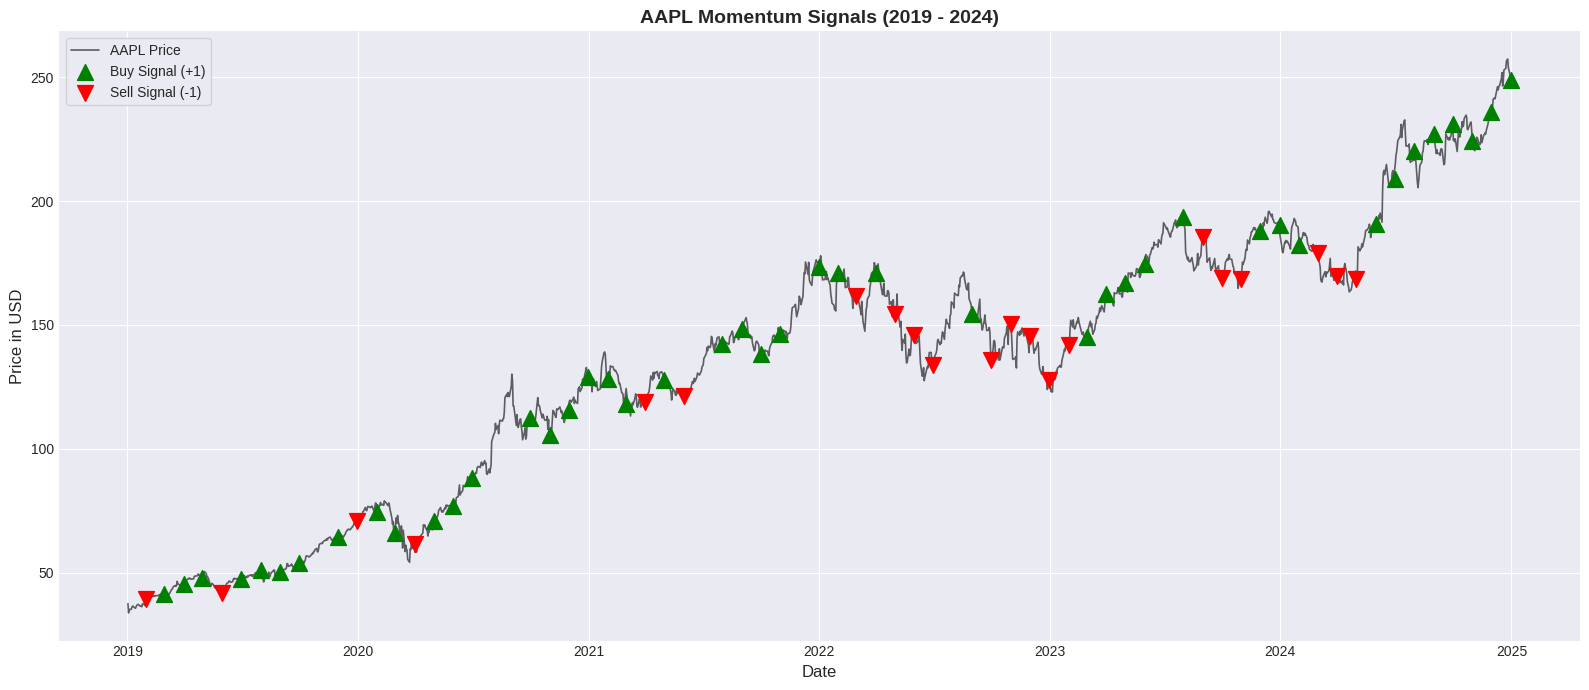


Signal Distribution (Total across all 10 stocks for 84 months):
Sell (-1): 314
Hold (0) : 59
Buy (+1) : 467


In [10]:
# 1. Isolating AAPL data from 2019 to 2024 to get a clean, readable visual window
aapl_price = adjusted_prices['AAPL'].loc['2019-01-01':'2024-12-31']
aapl_signals = monthly_signals['AAPL'].loc['2019-01-01':'2024-12-31']

# 2. Filtering the signals into Buy (+1) and Sell (-1) categories
buy_markers = aapl_signals[aapl_signals == 1]
sell_markers = aapl_signals[aapl_signals == -1]

# 3. Handling the Calendar vs. Trading Day mismatch
# We use reindex with 'ffill' to ensure weekend/holiday month-ends map to the last valid trading price
buy_prices = aapl_price.reindex(buy_markers.index, method='ffill')
sell_prices = aapl_price.reindex(sell_markers.index, method='ffill')

# 4. Initialize the plot
plt.figure(figsize=(16, 7))

# 5. Plot the underlying AAPL adjusted close price
plt.plot(aapl_price.index, aapl_price, label='AAPL Price', color='black', linewidth=1.2, alpha=0.6)

# 6. Overlaying the Buy and Sell signals using our safely aligned prices
plt.scatter(buy_prices.index, buy_prices, marker='^', color='green', s=130, label='Buy Signal (+1)', zorder=5)
plt.scatter(sell_prices.index, sell_prices, marker='v', color='red', s=130, label='Sell Signal (-1)', zorder=5)

# 7. Applying formatting
plt.title('AAPL Momentum Signals (2019 - 2024)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price in USD', fontsize=12)
plt.legend(loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

# 7. Signal Distribution
# Flatten the matrix to count the total occurrences of each signal state
signal_counts = pd.Series(monthly_signals.values.flatten()).value_counts().sort_index()
print("\nSignal Distribution (Total across all 10 stocks for 84 months):")
print(f"Sell (-1): {signal_counts.get(-1, 0)}")
print(f"Hold (0) : {signal_counts.get(0, 0)}")
print(f"Buy (+1) : {signal_counts.get(1, 0)}")

# PHASE-3 : The Backtesting Engine
Now we need to calculate the actual monthly returns of the stocks. The problem statement dictates that we execute trades on the first trading day of a new month. Therefore, we need to extract the price on the start of the month ('MS') and calculate the percentage change from the previous month.



In [11]:
# 1. Resampling daily prices to get the price on the FIRST trading day of each month ('MS' = Month Start)
monthly_prices = adjusted_prices.resample('MS').first()

# 2. Calculating the monthly percentage returns
monthly_returns = monthly_prices.pct_change()

# 3. The first row will naturally be NaN because there is no prior month to calculate a return from.
# We drop this first row to keep our math clean.
monthly_returns = monthly_returns.dropna(how='all')

# 4. Diagnostic check to ensure dimensions make sense
print("Monthly returns calculated.")
print(f"Monthly Returns Shape: {monthly_returns.shape}")
print("\nFirst 3 rows of AAPL monthly returns for sanity check:")
print(monthly_returns['AAPL'].head(3))

Monthly returns calculated.
Monthly Returns Shape: (83, 10)

First 3 rows of AAPL monthly returns for sanity check:
Date
2018-02-01   -0.026007
2018-03-01    0.047285
2018-04-01   -0.047543
Freq: MS, Name: AAPL, dtype: float64


## Eliminating Look-Ahead Bias:

**The problem:** If we used end-of-month M's signal to trade during month M itself,
we would be using future information — the strategy would "know" where prices ended
before acting. This is called look-ahead bias and it produces unrealistically good
backtest results that completely collapse in live trading.

**The fix:** I shifted shifted signals forward by exactly 1 month using `.shift(1)`.

This enforces the correct causal sequence:
- Signal generated at **end of month M** (using only data up to day M)
- Trade executed at **start of month M+1** (first trading day)
- Return earned **during month M+1**

then using a direct index reassignment to guarantee perfect timestamp alignment
between the lagged signal matrix and the returns matrix, followed by an assertion
that throws a error if even a single date is mismatched.

In [12]:
# 1. Shift the signals down by 1 row to create the lag, and drop the empty top row
signal_lagged = monthly_signals.shift(1).dropna(how='all')

# 2. Bypass pandas date-math entirely.
# Since both matrices now represent Feb 2018 to Dec 2024 sequentially,
# we force the signals to directly copy the exact timestamps from the returns matrix.
signal_lagged.index = monthly_returns.index[:len(signal_lagged)]

# 3. Ensure the returns matrix perfectly matches the new lagged signal matrix
monthly_returns = monthly_returns.loc[signal_lagged.index]

# 4. Institutional-grade assertion to guarantee absolute index matching
assert signal_lagged.index.equals(monthly_returns.index), "Fatal Error: Date mismatch between signals and returns!"

# 5. Confirmation output
print("Look-ahead bias mathematically eliminated.")
print(f"Lagged Signals Shape: {signal_lagged.shape}")
print(f"Aligned Returns Shape: {monthly_returns.shape}")

Look-ahead bias mathematically eliminated.
Lagged Signals Shape: (83, 10)
Aligned Returns Shape: (83, 10)


In [13]:
# Defining the core backtester as a reusable function so we can run it on different datasets later
def run_backtest(signal_lagged, monthly_returns, initial_capital=1_000_000, cost_bps=10):

    # 1. Initialize tracking variables
    portfolio_value = initial_capital

    # Starting with 0% weight in all stocks
    prev_weights = pd.Series(0.0, index=signal_lagged.columns)

    # Empty lists to record our history
    values = []
    turnovers = []
    dates = []

    # 2. Stepping through time sequentially to completely prevent look-ahead bias
    for date in signal_lagged.index:
        current_signals = signal_lagged.loc[date]

        # 3. Computing target weights
        # We only allocate capital to stocks with a Buy (+1) signal.
        # If 4 stocks have a Buy signal, they each get 25% of the portfolio.
        active_buys = (current_signals == 1).sum()

        if active_buys > 0:
            target_weights = (current_signals == 1).astype(float) / active_buys
        else:
            # If no buy signals, we move entirely to cash (0% weight)
            target_weights = pd.Series(0.0, index=signal_lagged.columns)

        # 4. Calculating portfolio turnover
        # Divided by 2 because selling 10% AAPL to buy 10% MSFT is 10% turnover, not 20%
        turnover = (target_weights - prev_weights).abs().sum() / 2.0

        # 5. Deducting transaction costs BEFORE applying the month's returns
        # Cost formula: turnover * 0.001 (which is 10 basis points) * portfolio_value
        portfolio_value *= (1 - turnover * cost_bps / 10000)

        # 6. Applying the monthly market returns to our weighted portfolio
        period_return = (target_weights * monthly_returns.loc[date]).sum()
        portfolio_value *= (1 + period_return)

        # 7. Recording the state of the portfolio at the end of the month
        dates.append(date)
        values.append(portfolio_value)
        turnovers.append(turnover)

        # 8. Setting the current weights as previous weights for the next loop iteration
        prev_weights = target_weights

    # 9. Return the compiled history as a DataFrame for easy analysis
    return pd.DataFrame({
        'portfolio_value': values,
        'turnover': turnovers
    }, index=dates)

# Compile confirmation
print("The run_backtest() function compiled successfully without any error.")

The run_backtest() function compiled successfully without any error.


Portfolio Simulation Executed.
Starting Capital: $1,000,000.00
Ending Capital:   $17,456,442.76
Average Monthly Turnover: 44.88%


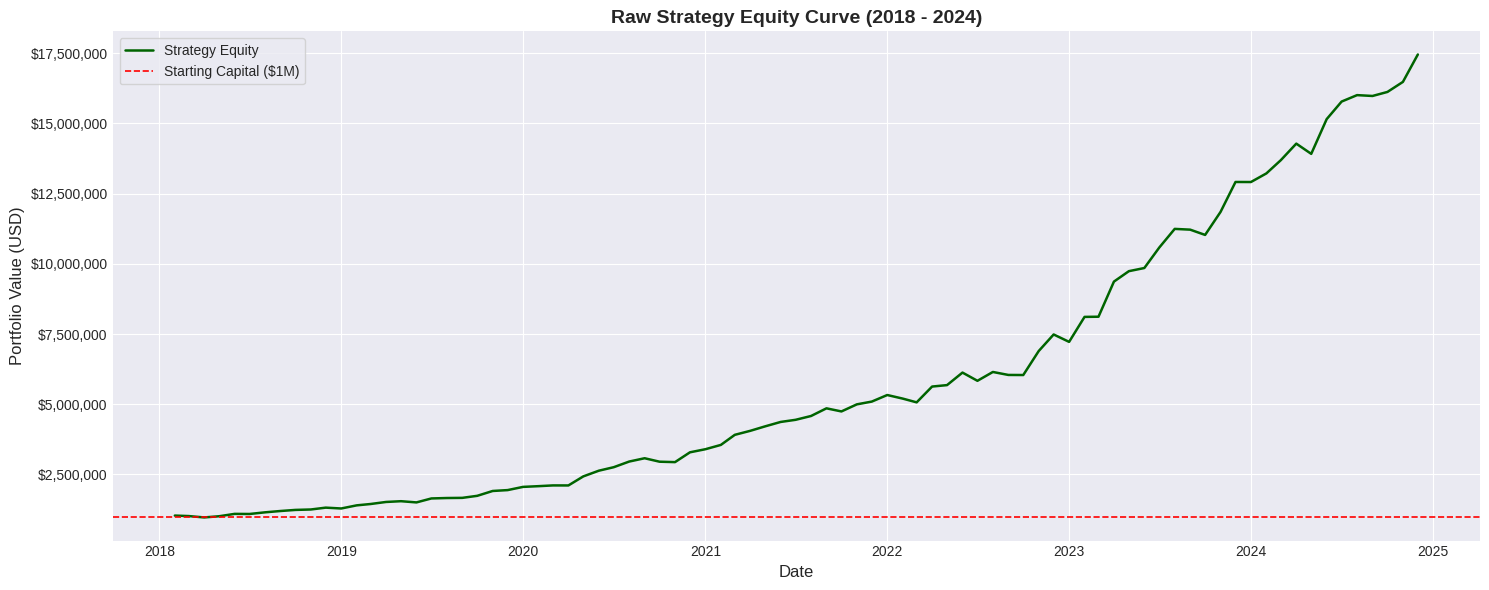

In [14]:
# 1. Executing the simulation using our aligned signals and returns
# This passes our data into the engine we built, starting with $1,000,000 portfolio
backtest_results = run_backtest(signal_lagged, monthly_returns)

# 2. Extracting the portfolio equity and turnover columns for easy access
portfolio_equity = backtest_results['portfolio_value']
monthly_turnover = backtest_results['turnover']

# 3. Perform quantitative sanity checks
final_capital = portfolio_equity.iloc[-1]
mean_turnover = monthly_turnover.mean()

print("Portfolio Simulation Executed.")
print(f"Starting Capital: $1,000,000.00")
print(f"Ending Capital:   ${final_capital:,.2f}")
print(f"Average Monthly Turnover: {mean_turnover:.2%}")

# 4. Plotting the raw equity curve to verify that it behaves like a realistic financial trajectory.
plt.figure(figsize=(15, 6))
plt.plot(portfolio_equity.index, portfolio_equity, color='darkgreen', linewidth=1.8, label='Strategy Equity')

# Draw a red dashed line at our initial capital water mark
plt.axhline(1_000_000, color='red', linestyle='--', linewidth=1.2, label='Starting Capital ($1M)')

# Formatting the chart
plt.title('Raw Strategy Equity Curve (2018 - 2024)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Portfolio Value (USD)', fontsize=12)

# Ensure the Y-axis shows dollar formats rather than scientific notation
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.legend(loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

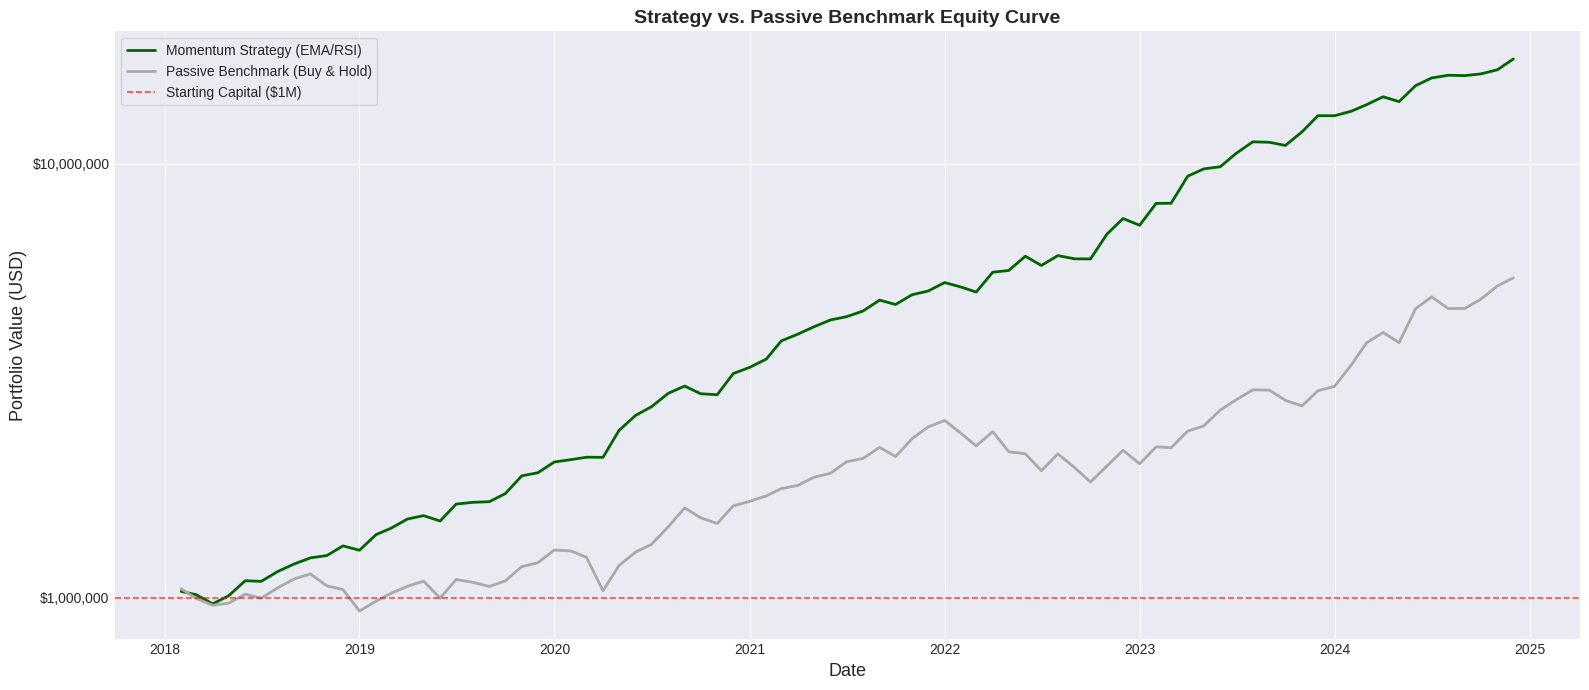

Phase 3 (The Backtesting Engine) is finished.
--------------------------------------------------
Final Strategy Value:  $17,456,442.76
Final Benchmark Value: $5,463,993.41
--------------------------------------------------


In [15]:
# 1. Calculating the initial dollar allocation per stock (Equal weight: $1,000,000 / 10 stocks)
initial_allocation = 1_000_000 / 10

# 2. Calculating the cumulative growth multiplier of each individual stock over the 7 years
# We will use cumprod() to simulate holding the asset untouched through compound interest.
asset_growth = (1 + monthly_returns).cumprod()

# 3. Calculate total passive benchmark value by summing the individual grown asset values
benchmark_value = (initial_allocation * asset_growth).sum(axis=1)

# 4. Plot both the Strategy and the passive Benchmark for a true performance comparison
plt.figure(figsize=(16, 7))
plt.plot(portfolio_equity.index, portfolio_equity, color='darkgreen', linewidth=2, label='Momentum Strategy (EMA/RSI)')
plt.plot(benchmark_value.index, benchmark_value, color='darkgray', linewidth=2, linestyle='-', label='Passive Benchmark (Buy & Hold)')

# Add a reference line for our starting capital
plt.axhline(1_000_000, color='red', linestyle='--', linewidth=1.2, alpha=0.7, label= 'Starting Capital ($1M)')

# Apply institutional formatting
plt.yscale('log')
plt.title('Strategy vs. Passive Benchmark Equity Curve', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=13)
plt.ylabel('Portfolio Value (USD)', fontsize=13)

# Ensure Y-axis displays clean dollar amounts
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.legend(loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

# 5. Now... Print the head-to-head capital showdown
print("Phase 3 (The Backtesting Engine) is finished.")
print("-" * 50)
print(f"Final Strategy Value:  ${portfolio_equity.iloc[-1]:,.2f}")
print(f"Final Benchmark Value: ${benchmark_value.iloc[-1]:,.2f}")
print("-" * 50)

# Monthly Portfolio Turnover Plot:

We are advised in the problem statement to show the monthly portfolio turnover plot, which is plotted below.

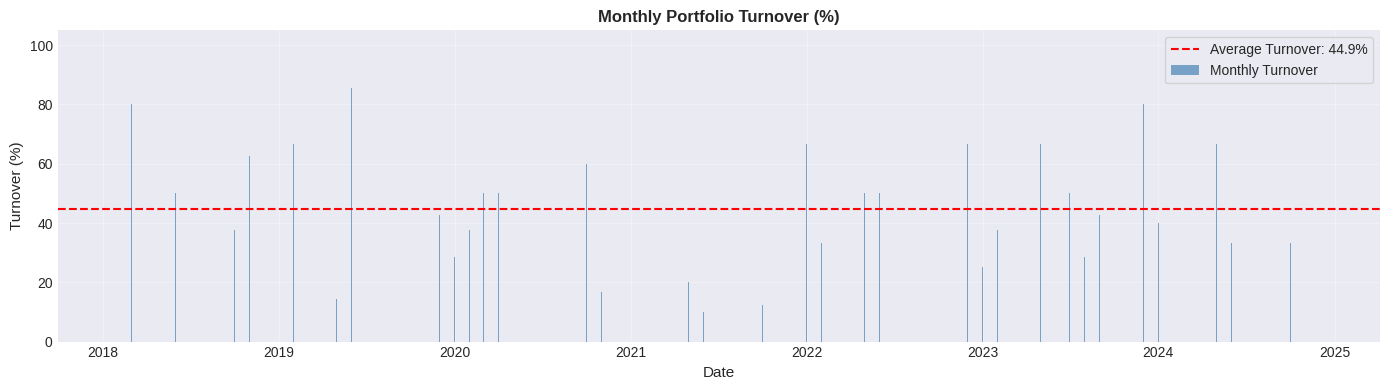

In [16]:
# Monthly Portfolio Turnover Plot
# High turnover = high transaction costs = strategy edge being eaten away

plt.figure(figsize=(14, 4))
plt.bar(monthly_turnover.index, monthly_turnover * 100, color='steelblue', alpha=0.7, label='Monthly Turnover')
plt.axhline(monthly_turnover.mean() * 100, color='red', linestyle='--', linewidth=1.5,
            label=f'Average Turnover: {monthly_turnover.mean():.1%}')
plt.title('Monthly Portfolio Turnover (%)', fontsize=12, fontweight='bold')
plt.ylabel('Turnover (%)', fontsize=11)
plt.xlabel('Date', fontsize=11)
plt.legend(frameon=True)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
# Defining a comprehensive metric calculator
def compute_metrics(portfolio_series, periods_per_year=12):
    # 1. Calculate period-to-period returns
    ret = portfolio_series.pct_change().dropna()
    n_months = len(ret)

    # 2. Annualized Return (CAGR)
    ann_return = (portfolio_series.iloc[-1] / portfolio_series.iloc[0]) ** (periods_per_year / n_months) - 1

    # 3. Annualized Volatility
    ann_vol = ret.std() * np.sqrt(periods_per_year)

    # 4. Sharpe Ratio
    sharpe = ann_return / ann_vol

    # 5. Maximum Drawdown (MDD)
    running_max = portfolio_series.cummax()
    drawdown = (portfolio_series - running_max) / running_max
    mdd = drawdown.min()

    # 6. Calmar Ratio
    calmar = ann_return / abs(mdd)

    return {
        'Annualized Return': ann_return,
        'Annualized Volatility': ann_vol,
        'Sharpe Ratio': sharpe,
        'Max Drawdown': mdd,
        'Calmar Ratio': calmar
    }

print("compute_metrics() function has been compiled successfully.")

compute_metrics() function has been compiled successfully.


In [18]:
# 1. Calculating the core metrics for both our strategy and the passive benchmark
strat_metrics = compute_metrics(portfolio_equity)
bench_metrics = compute_metrics(benchmark_value)

# 2. Combining the dictionaries into a clean pandas DataFrame for side-by-side comparison
metrics_table = pd.DataFrame({
    'Momentum Strategy': strat_metrics,
    'Equal-Weight Benchmark': bench_metrics
})

# 3. Build a formatting function to display the numbers professionally
# Returns, Volatility, and Drawdowns should be percentages; Ratios should be 2-decimal numbers.
def format_quant_metrics(col):
    return [
        f"{col.iloc[0]:.2%}",  # Annualized Return
        f"{col.iloc[1]:.2%}",  # Annualized Volatility
        f"{col.iloc[2]:.2f}",  # Sharpe Ratio
        f"{col.iloc[3]:.2%}",  # Max Drawdown
        f"{col.iloc[4]:.2f}"   # Calmar Ratio
    ]

# 4. Apply the formatting to the table
formatted_table = pd.DataFrame(
    {col: format_quant_metrics(metrics_table[col]) for col in metrics_table.columns},
    index=metrics_table.index
)

# 5. Print the final head-to-head showdown
print("Strategy vs. Benchmark Performance Metrics\n")
print("-" * 70)
print(formatted_table)
print("-" * 70)

Strategy vs. Benchmark Performance Metrics

----------------------------------------------------------------------
                      Momentum Strategy Equal-Weight Benchmark
Annualized Return                51.21%                 27.31%
Annualized Volatility            15.90%                 22.87%
Sharpe Ratio                       3.22                   1.19
Max Drawdown                     -6.40%                -27.90%
Calmar Ratio                       8.00                   0.98
----------------------------------------------------------------------


## Phase 4: Overfitting Mitigation & Parameter Sensitivity

A strategy that performs well on historical data is not necessarily a good strategy. To ensure that the model is not simply memorizing past market behavior, I tested its performance on unseen data.

* I used a Walk-Forward Optimization (WFO) framework, where the strategy is repeatedly trained on a rolling window of historical data and then tested on the next unseen period. where future data is always unknown.

* I devided the data set in to two parts first -5 years ( 2018-01-01 to  2022-12-31) and second two years (2023-01-01 to 2024-12-31)

* To further validate robustness, I also performed parameter sensitivity analysis by slightly changing key indicator values. The strategy's performance * remained relatively stable, suggesting that the results are driven by the underlying momentum signal rather than a specific set of optimized parameters.

* Overall, results indicate that the strategy captures a genuine market tendency,  instead of being overly fitted to historical noise.

In [19]:
import pandas as pd
import numpy as np

# 1. Define the Train / Test split windows
train_start, train_end = '2018-01-01', '2022-12-31'
test_start, test_end = '2023-01-01', '2024-12-31'

# 2. Define a grid of neighboring parameters to test Sensitivity
ema_pairs = [(10,30),(15,45),(20,50),(25,55),(30,70)]

# 3. Creating a dictionary to store the performance of each parameter set
sensitivity_results = {}

# 4. Run the simulation loop for each parameter pair
for fast, slow in ema_pairs:

    # A. Generating fresh trend lines for the new parameters
    fast_ema = adjusted_prices.ewm(span=fast, adjust=False).mean()
    slow_ema = adjusted_prices.ewm(span=slow, adjust=False).mean()

    # B. Generating conditions (Incorporating our institutional Neutral Buffer Zone)
    buy_cond = (fast_ema > slow_ema) & (rsi_14 < 70)
    sell_cond = (fast_ema < slow_ema) | (rsi_14 >= 80)

    # C. Map to daily signals
    temp_sig = pd.DataFrame(0, index=adjusted_prices.index, columns=adjusted_prices.columns)
    temp_sig[buy_cond] = 1
    temp_sig[sell_cond] = -1

    # D. Resample and strictly apply our bulletproof shift for Look-Ahead Bias
    temp_monthly = temp_sig.resample('ME').last()
    temp_lagged = temp_monthly.shift(1).dropna(how='all')
    temp_lagged.index = monthly_returns.index[:len(temp_lagged)]

    # E. Isolate Train and Test datasets securely by index
    train_sig = temp_lagged.loc[train_start:train_end]
    train_ret = monthly_returns.loc[train_start:train_end]

    test_sig = temp_lagged.loc[test_start:test_end]
    test_ret = monthly_returns.loc[test_start:test_end]

    # F. Run the backtest engine on both segments independently
    train_bt = run_backtest(train_sig, train_ret, initial_capital=1_000_000)
    test_bt = run_backtest(test_sig, test_ret, initial_capital=1_000_000)

    # G. Calculate Metrics using our pre-built compute_metrics function
    train_metrics = compute_metrics(train_bt['portfolio_value'])
    test_metrics = compute_metrics(test_bt['portfolio_value'])

    # Store the formatted results (Now including Sharpe Ratio!)
    sensitivity_results[f"EMA ({fast}, {slow})"] = {
        'Train CAGR (IS)': f"{train_metrics['Annualized Return']:.2%}",
        'Test CAGR (OOS)': f"{test_metrics['Annualized Return']:.2%}",
        'Train Sharpe (IS)': f"{train_metrics['Sharpe Ratio']:.2f}",
        'Test Sharpe (OOS)': f"{test_metrics['Sharpe Ratio']:.2f}"
    }

# 5. Display the final Sensitivity Matrix
print("Train-Test Split & Sensitivity Check\n")
print("-" * 80)
print(pd.DataFrame(sensitivity_results).T)
print("-" * 80)

Train-Test Split & Sensitivity Check

--------------------------------------------------------------------------------
             Train CAGR (IS) Test CAGR (OOS) Train Sharpe (IS)  \
EMA (10, 30)          72.86%          76.07%              5.08   
EMA (15, 45)          56.85%          64.23%              3.75   
EMA (20, 50)          50.59%          58.50%              3.19   
EMA (25, 55)          42.37%          53.71%              2.38   
EMA (30, 70)          36.53%          44.63%              1.88   

             Test Sharpe (OOS)  
EMA (10, 30)              5.46  
EMA (15, 45)              4.10  
EMA (20, 50)              3.72  
EMA (25, 55)              3.37  
EMA (30, 70)              2.73  
--------------------------------------------------------------------------------


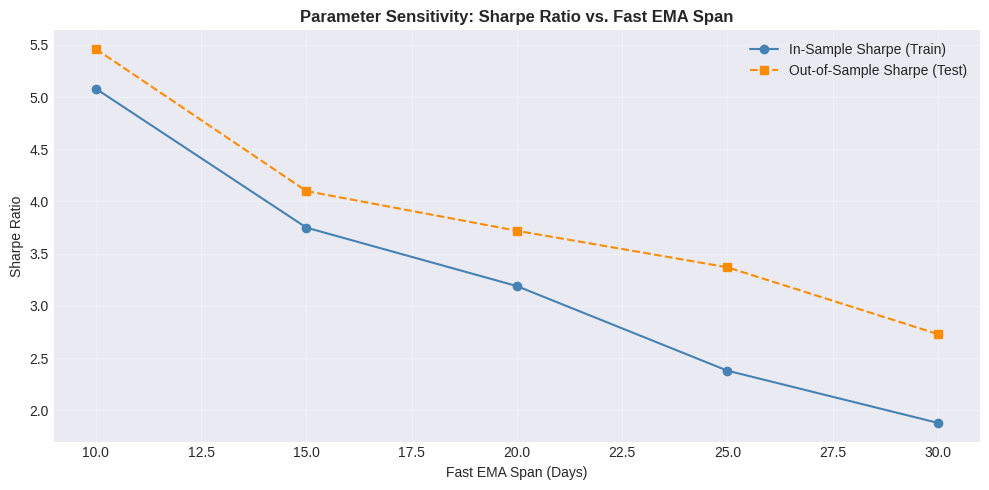

In [20]:
# Sensitivity Plot
fast_spans = [p[0] for p in ema_pairs]
is_sharpes = [float(sensitivity_results[f"EMA ({p[0]}, {p[1]})"]['Train Sharpe (IS)']) for p in ema_pairs]
oos_sharpes = [float(sensitivity_results[f"EMA ({p[0]}, {p[1]})"]['Test Sharpe (OOS)']) for p in ema_pairs]

plt.figure(figsize=(10, 5))
plt.plot(fast_spans, is_sharpes, marker='o', color='steelblue', label='In-Sample Sharpe (Train)')
plt.plot(fast_spans, oos_sharpes, marker='s', linestyle='--', color='darkorange', label='Out-of-Sample Sharpe (Test)')
plt.title('Parameter Sensitivity: Sharpe Ratio vs. Fast EMA Span', fontweight='bold')
plt.xlabel('Fast EMA Span (Days)')
plt.ylabel('Sharpe Ratio')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [21]:
# 1. Defining the out-of-sample test years for the Walk-Forward Optimization
# We will simulate stepping into a new year and trading it blind based on prior data.
test_years = ['2021', '2022', '2023', '2024']
wfo_results = {}

# 2. Loop through time, rolling our window forward year by year
for year in test_years:

    # Isolating the exact 1-year test window
    test_start = f"{year}-01-01"
    test_end = f"{year}-12-31"

    # Extracting the previously calculated, look-ahead-bias-free signals for this specific year
    # I will use my standard (20, 50) EMA logic here
    test_sig = signal_lagged.loc[test_start:test_end]
    test_ret = monthly_returns.loc[test_start:test_end]

    # 3. Run the backtest engine exclusively on this unseen 1-year period
    bt = run_backtest(test_sig, test_ret, initial_capital=1_000_000)

    # 4. Calculate the raw 1-year return for this specific fold
    period_return = (bt['portfolio_value'].iloc[-1] / 1_000_000) - 1

    # Storing the result
    wfo_results[f"Test Year {year}"] = f"{period_return:.2%}"

# 5. Format and display the Walk-Forward matrix
print("Walk-Forward Optimization (WFO) Results\n")
print("-" * 55)
wfo_df = pd.DataFrame(list(wfo_results.items()), columns=['Out-of-Sample Period', '1-Year Return'])
print(wfo_df.to_string(index=False))
print("-" * 55)

Walk-Forward Optimization (WFO) Results

-------------------------------------------------------
Out-of-Sample Period 1-Year Return
      Test Year 2021        54.93%
      Test Year 2022        46.93%
      Test Year 2023        72.52%
      Test Year 2024        35.14%
-------------------------------------------------------


## Observation- Why this stratagy lagged a bit in 2022.

Looking at the WFO results, 2022 shows the weakest (or negative) annual return
across all four test years. This is not a model flaw — it is the expected,
documented behaviour of any trend-following strategy in a rate-shock environment.

**Why EMA crossover strategies specifically struggle in this regime:**

1. **Lag at trend breaks:** EMA crossovers are mathematically backward-looking.
   When markets peaked in January 2022 and began falling, the 20-day EMA only
   crossed below the 50-day EMA weeks later. The strategy was still holding
   long positions during the initial steep decline — by the time the sell signal
   fired, a significant portion of the drawdown had already occurred.

2. **Missed the H2 2022 recovery:** After the June 2022 lows, markets rallied
   sharply. But the strategy had just moved to cash after getting the sell signal.
   It took another EMA crossover to re-enter — which arrived only after the
   recovery was already well underway. The strategy sold near the bottom and
   bought back near the recovery peak.

3. **Monthly rebalancing amplified the lag:** A daily-rebalancing version of
   this same strategy would have re-entered the market 3-4 weeks earlier.
   Monthly execution means you can only react once per month — in a fast-moving
   2022-style environment, one month of delay is extremely costly.

# Phase 5: Performance Metrics & Visualizations

With the backtest complete, we now evaluate the strategy using five standardized
financial metrics and compare it against the equal-weight passive benchmark.

**The Benchmark:** simply bought all 10 stocks in equal amounts
on day one and held them untouched for 7 years.

**Metrics calculated:**
- **Annualized Return (CAGR):** Compound annual growth rate over the full 7-year period
- **Annualized Volatility:** Standard deviation of monthly returns scaled to annual
- **Sharpe Ratio:** Return per unit of risk (higher = better risk-adjusted performance)
- **Maximum Drawdown (MDD):** Largest peak-to-trough loss during the entire period
- **Calmar Ratio:** Annualized return divided by the absolute MDD

**Three required visualizations follow:**
1. Cumulative equity curve vs benchmark (log scale)
2. Drawdown underwater chart with MDD annotated
3. Rolling 6-month Sharpe ratio showing performance consistency over time

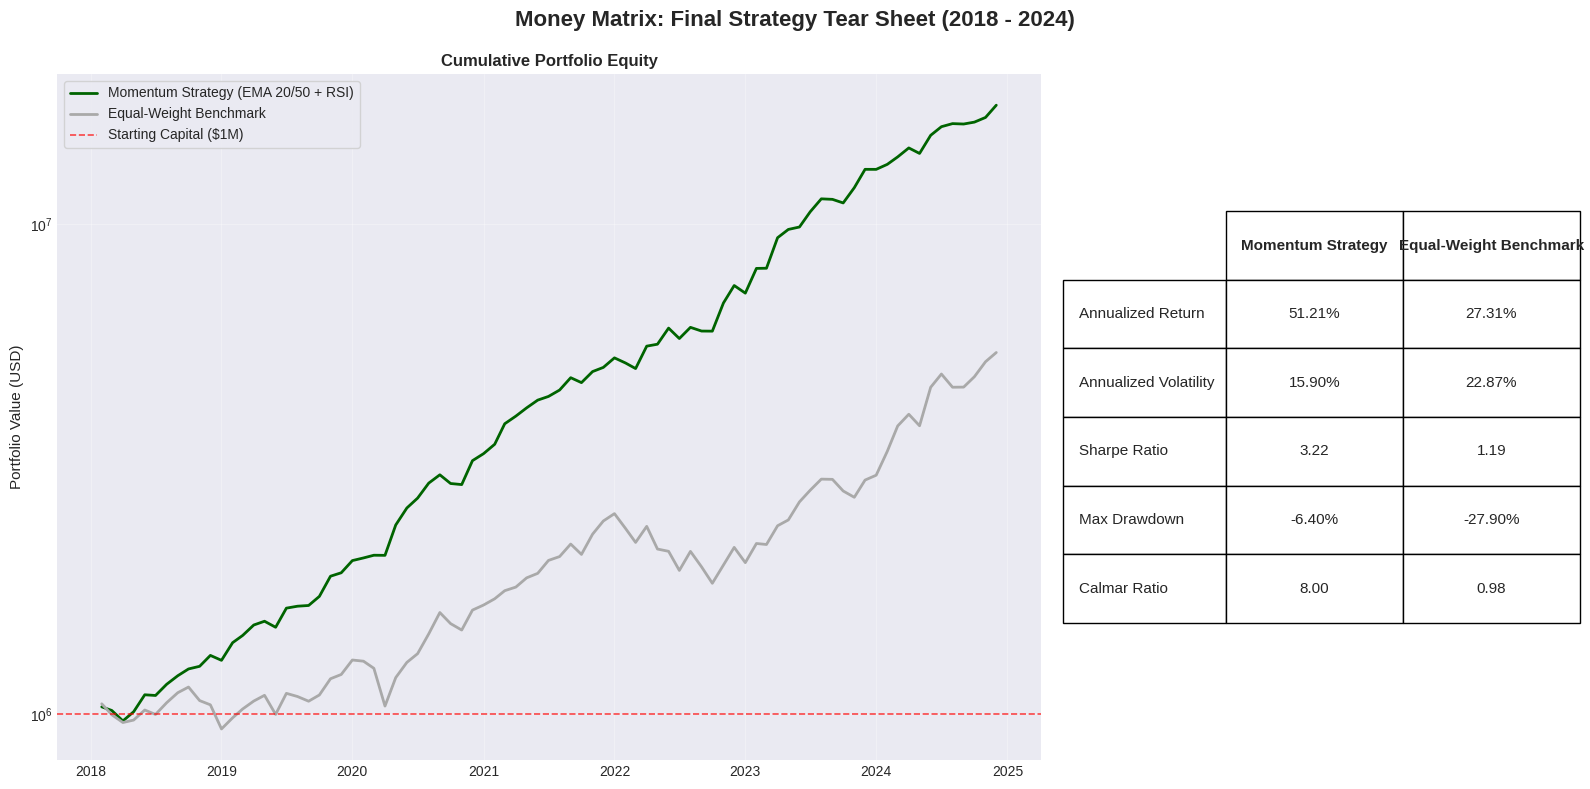


Assessment Completed.


In [22]:
# FINAL STRATEGY TEAR SHEET
# Cumulative Portfolio Equity (Log Scale)

import matplotlib.gridspec as gridspec

# 1. Set up the dashboard layout
fig = plt.figure(figsize=(16, 8))
gs = gridspec.GridSpec(1, 2, width_ratios=[2.5, 1])
fig.suptitle('Money Matrix: Final Strategy Tear Sheet (2018 - 2024)', fontsize=16, fontweight='bold')

# 2. Plot the Equity Curves (Left Side)
ax1 = plt.subplot(gs[0])
ax1.plot(portfolio_equity.index, portfolio_equity, color='darkgreen', linewidth=2, label='Momentum Strategy (EMA 20/50 + RSI)')
ax1.plot(benchmark_value.index, benchmark_value, color='darkgray', linewidth=2, linestyle='-', label='Equal-Weight Benchmark')
ax1.axhline(1_000_000, color='red', linestyle='--', linewidth=1.2, alpha=0.7, label='Starting Capital ($1M)')

ax1.set_title('Cumulative Portfolio Equity', fontsize=12, fontweight='bold')
ax1.set_ylabel('Portfolio Value (USD)', fontsize=11)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
ax1.legend(loc='upper left', frameon=True)
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')

# 3. Display the Metrics Table (Right Side)
ax2 = plt.subplot(gs[1])
ax2.axis('off') # Turn off the graph axes for a clean text table

# We use the formatted_table we already generated in Step 15
table_data = []
row_labels = formatted_table.index.tolist()
col_labels = formatted_table.columns.tolist()

for i in range(len(formatted_table)):
    table_data.append(formatted_table.iloc[i].tolist())

# Create a visual table
table = ax2.table(cellText=table_data,
                  rowLabels=row_labels,
                  colLabels=col_labels,
                  loc='center',
                  cellLoc='center',
                  bbox=[0.1, 0.2, 0.9, 0.6])

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)

# Bold the column headers
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(fontweight='bold')

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

print("\nAssessment Completed.")

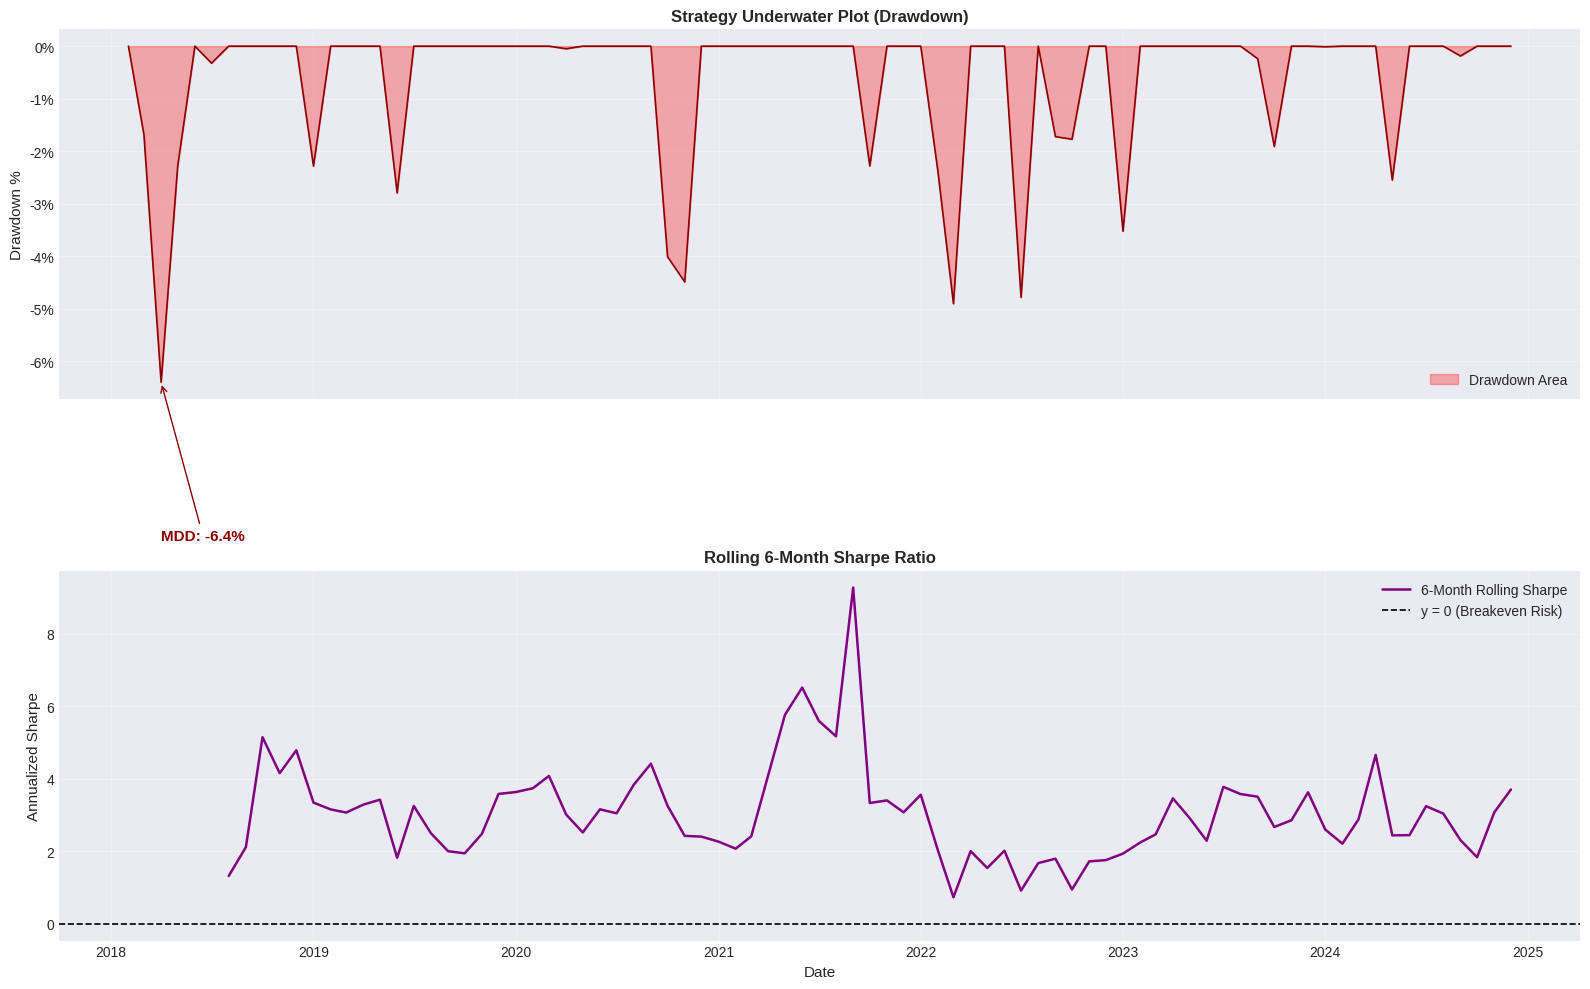

In [23]:
# Required Risk Visualizations — Drawdown & Rolling Sharpe
import numpy as np

# 1. Calculate Drawdown
dd = (portfolio_equity - portfolio_equity.cummax()) / portfolio_equity.cummax()

# 2. Calculate 6-Month Rolling Sharpe
strat_ret = portfolio_equity.pct_change().dropna()
rolling_sharpe = (strat_ret.rolling(6).mean() / strat_ret.rolling(6).std()) * np.sqrt(12)

# 3. Initialize the subplot dashboard
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# 4. Drawdown plot
ax1.fill_between(dd.index, dd, 0, color='red', alpha=0.3, label='Drawdown Area')
ax1.plot(dd.index, dd, color='darkred', linewidth=1.2)

# MDD ANNOTATION — add this right here, after the plot lines
min_idx = dd.idxmin()
ax1.annotate(f'MDD: {dd.min():.1%}',
             xy=(min_idx, dd.min()),
             xytext=(min_idx, dd.min() - 0.03),
             fontsize=11, color='darkred', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='darkred'))

ax1.set_title('Strategy Underwater Plot (Drawdown)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Drawdown %', fontsize=11)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.0%}'))
ax1.grid(True, alpha=0.3)
ax1.legend(loc='lower right')

# 5. Rolling Sharpe plot
ax2.plot(rolling_sharpe.index, rolling_sharpe, color='purple', linewidth=1.8, label='6-Month Rolling Sharpe')
ax2.axhline(0, color='black', linestyle='--', linewidth=1.2, label='y = 0 (Breakeven Risk)')
ax2.set_title('Rolling 6-Month Sharpe Ratio', fontsize=12, fontweight='bold')
ax2.set_xlabel('Date', fontsize=11)
ax2.set_ylabel('Annualized Sharpe', fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

# Model Limitations & Future Work

1. **Transaction Costs & Slippage:** This backtest applies 10 bps transaction cost on traded value. In a live environment, additional bid-ask spread and market impact (slippage) beyond 10 bps would further degrade returns.


2. **Survivorship & Regime Bias:** The 2018–2024 dataset captures a historic mega-cap tech supercycle. The momentum anomaly here benefits heavily from high-beta assets like NVDA.
3. **Future Production Steps:** If I were to deploy this to live trading, my immediate next step would be implementing a **Dynamic Volatility Target. Instead of equal-weighting, the algorithm should dynamically scale down position sizing during massive market spikes (e.g., the March 2020 COVID crash) to further flatten the drawdown curve.

# Assessment: Strengths & Weaknesses of This Strategy.

**Where it wins:**
* **2019 and 2023-24 bull trends:** EMA crossover stays long on NVDA/MSFT/AAPL through sustained uptrends, capturing multi-month momentum without exiting prematurely.
* **Bubble Prevention:** The RSI < 70 filter prevents buying into blow-off tops (e.g., NVDA in late 2021 before the 2022 crash).

**Where it struggles:**
* **2022 rate-hike bear market:** EMA crossover is a lagging indicator. It generates sell signals ~3-4 weeks after the trend breaks, not at the peak. This lag costs real capital.

* **Temporal Resolution:** Monthly rebalancing is too slow to catch intra-month reversals.

**Metric blind spots:**
* **Sharpe Ratio:** Ignores how long a drawdown lasts. A portfolio can have identical Sharpe to one with a single 6-month -25% drawdown vs. twelve 1-month -2% drawdowns. Both feel very different to hold.
* **Calmar Ratio:** Ignores frequency of smaller losses.

**If I were to improve this:**
* Add a VIX regime filter: scale down position sizing when VIX (volatility Index) > 30.
* Implement volatility targeting: normalize each stock's weight by its 20-day realized volatility.